
# Validating the Python/JuPedSim PLEdestrians model against Guy et al. (2010)

This notebook checks a Python implementation of **PLEdestrians**, running
inside **JuPedSim**'s experimental `CustomOperationalModel` plugin API (the
same pattern as this repo's SFM and RVO notebooks), against the paper that
introduced it:

> S. J. Guy, J. Chhugani, S. Curtis, P. Dubey, M. Lin, D. Manocha.
> *PLEdestrians: A Least-Effort Approach to Crowd Simulation.*
> Eurographics/ACM SIGGRAPH Symposium on Computer Animation (SCA) 2010,
> pp. 119–128. [doi:10.2312/SCA/SCA10/119-128](https://doi.org/10.2312/SCA/SCA10/119-128)

**The model in one paragraph.** Walking at speed *v* costs metabolic power
`P/m = e_s + e_w |v|²` (Eq. 1, with `e_s = 2.23 J/(kg s)`,
`e_w = 1.26 J s/(kg m²)` from treadmill data). Energy over a path is
minimised by walking straight at `√(e_s/e_w) = 1.33 m/s` (Lemma 1), and
costs at least `2 L √(e_s e_w)` for a length *L* (Corollary 1). Each step,
every agent picks, among the collision-free "permissible velocities" `PV_A`
given by ORCA [vdBGLM09], the velocity that minimises the energy of holding
it for τ seconds plus the least possible energy for the rest of the way
(Eq. 4). A dynamic energy-weighted roadmap routes agents around congestion
(Sec. 4.2).

**How the paper validated it** (from `model_description.md`, checked
against the PDF), and what each result measures:

| Paper result | What it measures | Type |
|---|---|---|
| Table 1, #1 "2-Agent swapping" | energy (J/kg) and time vs. ClearPath, OpenSteer, Helbing, RVO; "within 99% of the theoretical minimum" | numbers |
| Table 1, #2 "10-Agent Circle" | energy and time, same five methods; PLE lowest | numbers |
| Table 1, #3 "Concentric Circles" (34 + 66 agents) | energy and time, same five methods; PLE lowest | numbers |
| Fig. 8 | 2-agent crossing paths, PLE vs. Helbing: "less deviation and effort" | picture |
| Fig. 7 | average speed vs. area per person, against Fruin (1971) and Nelson & Maclennan (1995) | numeric plot |
| Fig. 9 | speed across the Long Corridor: edges 33% faster than the centre | numeric plot + number |
| Fig. 6a/b/c | Long Corridor (uneven densities), Narrow Passage (jamming, arching, wake), Concentric Circles (congestion avoidance) | pictures |
| Fig. 10 | Trade-show floor: energy per agent vs. N, against ClearPath and RVO | numeric plot |
| Fig. 1 | Shibuya crossing, side by side with real video | pictures |
| Table 2 | frame rate for the three largest scenes | numbers |

**What this notebook does:** Sections 1–5 reproduce Table 1 with Fig. 8,
the Concentric Circles picture (Fig. 6c), the Long Corridor with its edge
effect (Figs. 6a, 9), the speed–density comparison (Fig. 7), and the Narrow
Passage (Fig. 6b). For Table 1 we also run this repo's finished **RVO**
(`RVO/pyrvo.py`) and **Helbing social-force** (`SFM/pysocial_force.py`)
models on the same setups, because two of the paper's comparison methods
are available here. Section 6 covers what we could not reproduce (the
trade-show floor, Shibuya, and Table 2's frame rates) and says why.

**Code layout** (all in `PLEdestrians/`):

- `pyPLEdestrians.py`: the model (`PLEdestriansModel`, `PLEState`).
- `validation/run_table1.py`, `run_corridor.py`, `run_narrow_passage.py`:
  one runner per paper experiment; `run_everything.sh` regenerates all of
  them (each sweep point as its own OS process).
- `validation/analysis.py`: trajectory loading and metrics;
  `validation/digitize_figures.py`: digitization of Figs. 7, 9, 10.
- `validation/results/`: `.sqlite` trajectories, `.json` run summaries,
  `plot_*.png`, and `paper_fig*.png` crops of the PDF.


In [1]:

import pathlib
import sys

# jupedsim is not pip-installed; its Python package and compiled bindings are
# made importable via PYTHONPATH (see jupedsim/build/environment). Jupyter
# kernels don't inherit that, so replicate it here. The kernel cwd is this
# notebook's folder (PLEdestrians/), matching the pathlib.Path("validation") usage below.
_REPO = pathlib.Path.cwd().parent
_JP = _REPO / "jupedsim"
for _d in (
    _JP / "python_modules" / "jupedsim",
    _JP / "python_modules" / "jupedsim_visualizer",
    _JP / "python_modules" / "jupedsim_examples",
    _JP / "build" / "lib",
):
    _p = str(_d.resolve())
    if _p not in sys.path:
        sys.path.insert(0, _p)

# sanity check
from jupedsim.internal.notebook_utils import animate, read_sqlite_file
print("jupedsim import OK")


jupedsim import OK


In [2]:

import json
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shapely
from shapely import wkt

import sys
sys.path.insert(0, str(pathlib.Path("validation").resolve()))
sys.path.insert(0, str(pathlib.Path(".").resolve()))
from analysis import (
    ES, EW, voronoi_density, load_trajectory, add_velocity, arrival_times, effort_per_agent,
    min_clearance, lateral_speed_profile, speed_density_samples, overtakes,
    crossing_times, occupancy_map,
)
from pyPLEdestrians import min_energy

RESULTS = pathlib.Path("validation/results")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# Same caveat as the SFM and RVO notebooks: this is JuPedSim's own internal
# replay utility. Its module docstring says explicitly "We make no promises
# about the functions from this file w.r.t. API stability... Do not use the
# code here. Use it at your own peril." We use it anyway, for the same
# reason -- there isn't a public, stable alternative.
from jupedsim.internal.notebook_utils import animate, read_sqlite_file

AGENT_RADIUS = 0.3
V_DES = np.sqrt(ES / EW)
MODEL_COLORS = {"ple": "tab:blue", "rvo": "tab:green", "sfm": "tab:red"}
MODEL_NAMES = {"ple": "PLE (ours)", "rvo": "RVO (repo model)", "sfm": "Helbing SFM (repo model)"}


def load_run(tag):
    s = json.loads((RESULTS / f"{tag}.json").read_text())
    df, _ = load_trajectory(RESULTS / f"{tag}.sqlite")
    return s, df



### Reference values from the original paper

Every plot below also shows the paper's own result, in black, labelled
"paper".

- **Table 1** is copied as printed.
- **Figs. 7, 9 and 10** were **digitized**. Each PDF page was rendered at
  300 dpi (`pdftoppm -r 300`) and each figure was cropped. Each curve was
  then traced by its line colour, column by column inside the plot area,
  and converted to data units using the gridline pixel rows and the tick
  labels (`validation/digitize_figures.py`). The traced points were checked
  by drawing them back onto the crops. Accuracy is about ±0.01 m/s for the
  speed axes, ±0.03 m² for area per person, ±0.15 m for Fig. 9's x axis,
  and ±15 J/kg for Fig. 10. Where two of Fig. 7's curves overlap (area per
  person above ~3.5 m²), the tracer loses the one drawn underneath, so
  those points are missing.
- **Nelson & Maclennan** is also drawn from the formula the paper quotes,
  `S = k(1 − αρ)` with `k = 1.4`, `α = 0.266`.
- **Claims stated in words** become reference values:
  - "within 99% of the theoretical minimum energy" (Sec. 6) becomes
    `E ≤ 1.01 · E_min`, with `E_min` from Corollary 1.
  - "agents at the left (0m) and right (25m) are moving 33% faster than
    those in the center (12.5m)" becomes an edge/centre speed ratio of 1.33.
  - "all agents reach their goals" (Narrow Passage) becomes 100% arrival.
  - hard disks with no overlaps become a minimum clearance of 0 m.
- **Pictures** (Figs. 6, 8, 10 and Table 1) are crops of the 300 dpi pages
  and are shown next to our own plots.


In [3]:

# Table 1, as printed. Energy in J/kg, time in s. Columns: #1 2-agent swap,
# #2 10-agent circle, #3 concentric circles. (*OpenSteer collides in #3.)
PAPER_TABLE1 = {
    "ClearPath": {"energy": [33.4, 39.8, 315], "time": [7.5, 11.3, 124.5]},
    "OpenSteer": {"energy": [36.1, 43.7, 251], "time": [8.1, 10.5, 54]},
    "Helbing":   {"energy": [39.3, 45.6, 211], "time": [10.0, 14.2, 70.5]},
    "RVO":       {"energy": [33.9, 42.1, 195], "time": [7.6, 13.3, 64.0]},
    "PLE":       {"energy": [33.3, 35.7, 183], "time": [7.5, 10.4, 61.7]},
}
PAPER_MIN_ENERGY_FACTOR = 1.01  # Sec. 6: "within 99% of the theoretical minimum"

# Digitized (validation/digitize_figures.py). Fig. 7: area per person [m^2]
# vs. average speed [m/s].
PAPER_FIG7 = {
    "ple": {"area_per_person": [0.35, 0.4, 0.45, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.2, 1.4, 1.7, 2.0, 2.5, 3.0, 3.5],
            "speed": [0.581, 0.663, 0.699, 0.735, 0.789, 0.886, 1.006, 1.073, 1.126, 1.19, 1.215, 1.243, 1.26, 1.287, 1.308, 1.323]},
    "nelson": {"area_per_person": [0.35, 0.4, 0.45, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.2, 1.4, 1.7, 2.0, 2.5, 3.0, 3.5, 4.0],
               "speed": [0.496, 0.604, 0.694, 0.759, 0.869, 0.946, 1.001, 1.048, 1.081, 1.135, 1.173, 1.213, 1.232, 1.265, 1.295, 1.317, 1.327]},
    "fruin": {"area_per_person": [0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.2, 1.4, 1.7, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5],
              "speed": [0.563, 0.723, 0.836, 0.921, 0.997, 1.052, 1.137, 1.195, 1.231, 1.249, 1.272, 1.29, 1.305, 1.313, 1.323]},
}
NELSON_K, NELSON_ALPHA = 1.4, 0.266  # S = k (1 - alpha rho), as quoted in Sec. 5.3

# Fig. 9: lateral position across the 25 m corridor [m] vs. average speed [m/s].
PAPER_FIG9 = {
    "x": [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0],
    "speed": [1.33, 1.331, 1.319, 1.288, 1.243, 1.189, 1.139, 1.098, 1.067, 1.046, 1.034, 1.025, 1.022, 1.025, 1.04, 1.066, 1.096, 1.134, 1.186, 1.235, 1.279, 1.311, 1.328, 1.328],
}
PAPER_EDGE_RATIO = 1.33  # text: edges "33% faster" than the centre

# Fig. 10: trade-show floor, number of agents vs. average energy per agent [J/kg].
PAPER_FIG10 = {
    "clearpath": {"n_agents": [750, 800, 850, 900, 950, 1000, 1050, 1100], "energy": [764, 867, 974, 1090, 1217, 1381, 1605, 1931]},
    "rvo": {"n_agents": [750, 800, 850, 900, 950, 1000, 1050, 1100, 1150, 1200, 1250, 1300, 1350, 1400],
            "energy": [567, 600, 637, 683, 725, 776, 817, 855, 897, 939, 990, 1040, 1086, 1140]},
    "ple": {"n_agents": [750, 800, 850, 900, 950, 1000, 1050, 1100, 1150, 1200, 1250, 1300, 1350, 1400],
            "energy": [394, 398, 403, 411, 419, 432, 436, 440, 444, 453, 470, 495, 512, 537]},
}
# Table 2: frames per second on one core (Intel i7 965, 3.2 GHz).
PAPER_TABLE2 = {"Long Corridor": (10000, 15.1), "Shibuya": (1000, 29.9), "Trade-show": (1000, 31.0)}

PAPER_MIN_CLEARANCE = 0.0
PAPER_PASSAGE_ARRIVED = 1.0
PAPER_IMG = {k: RESULTS / f"paper_{k}.png" for k in [
    "table1", "fig6a_long_corridor", "fig6b_narrow_passage", "fig6c_concentric",
    "fig7_speed_density", "fig8_two_agent_paths", "fig9_edge_effect", "fig10_tradeshow"]}
PAPER_STYLE = dict(color="black", ls="--", alpha=0.7)



## Implementation notes: design choices, bugs found, and `dt`

**The optimisation is the paper's.** `pyPLEdestrians.py` builds `PV_A` as
ORCA's half-planes, written here from the ORCA paper. It does not use this
repo's `ORCA/` folder, which is still under construction. The velocity is
the minimiser of Eq. 4 over `PV_A`, found the way Sec. 4.3 describes: the
unconstrained optimum if it is permissible, otherwise the best point on the
boundary segments. On each segment the 1-D stationarity condition is the
paper's quartic (Eq. 7) before squaring. We solve it by safeguarded Newton
iteration on a monotone function instead of in closed form. This gives the
same point and avoids choosing among the quartic's roots. We checked the
optimiser against a brute-force grid on 650 random constraint sets: it was
never worse than the grid and always permissible.

**Things the paper does not specify, and what we did:**

- **τ, the look-ahead in Eq. 4.** No value is given. The data rule out a
  large τ: once the goal is closer than `τ·√(e_s/e_w)`, Eq. 4's optimum is
  `(G − p)/τ`, so the agent decelerates exponentially over its last
  `1.33·τ` metres. Table 1 #1's 7.5 s for 10 m equals exactly
  10 m / 1.33 m/s, which leaves no room for that. The scan below
  confirms this: τ ≥ 1 s makes the swap take 8.4 s or more. We use
  **τ = 0.5 s**, the largest value consistent with Table 1.
  Smaller values give the same results within seed noise.
- **Distance to the goal.** JuPedSim's step gives only the *direction* to
  the next target. Eq. 4 also needs the distance, so each agent
  dead-reckons its position (`p += v·dt`; the engine applies moves
  unchanged) and carries its goal. Every runner compares the dead-reckoned
  position with the engine's: the largest difference in every run is 0.
  Around obstacles, the direction comes from JuPedSim's router and the
  length from the straight-line goal distance. The paper aims at the next
  roadmap node (Sec. 4.1), whose distance the step does not expose.
- **ORCA's parameters** (time horizon 2 s, 0.5 s for walls, max speed
  2 m/s, the 10 nearest neighbours within 5 m). The paper says only that
  it uses "the closest neighboring agents" (Sec. 4.4). The radius is
  0.3 m, the paper's "at least 0.3m".
- **Not implemented: the kD-tree clustering of distant agents (Sec. 4.4)
  and the dynamic energy roadmap (Sec. 4.2).** Neither is specified in
  enough detail to reproduce: the constraint a cluster adds is not given,
  and the roadmap needs the scene's graph. Both mainly matter for the
  trade-show floor (Section 6).

**Beyond the paper, flagged in the code:**

- **Empty `PV_A`.** When ORCA's half-planes have no common point (dense
  crowds), we take the velocity that minimises the largest violation, with
  walls kept hard. This is ORCA's own Sec. 5.3 rule, solved as a small LP.
- **Already-overlapping pairs.** The half-plane separates them within one
  step, as ORCA's reference code does.

**Problems found while building it:**

1. **Symmetric deadlock in the 10-agent circle.** With identical agents,
   everyone walked into a packed ring (radius ≈ 1 m, 10 × 0.6 m diameters)
   and froze for good. The cause: each agent's two adjacent neighbours
   converge sideways and give mirror-image half-planes, whose wedge caps
   forward speed on the radial axis, so everyone brakes together. Once
   packed, standing still is the true optimum of Eq. 4, because walking
   sideways costs energy without getting closer. It is not a code error:
   we checked the half-plane construction term by term, and it froze for
   every τ (0.05–2 s) and ORCA horizon (0.5–10 s). The RVO2 remedy (a
   random ≤ 1e-4 m/s nudge to the preferred velocity) did not help, and
   neither did 0.01 m/s. What did help is what the paper stresses: agents
   are **heterogeneous**, with per-agent `e_s`, `e_w` (Sec. 3.1). We draw
   `√(e_s/e_w)` uniformly within ±10% of 1.33 m/s and keep `√(e_s e_w)`
   fixed, so Corollary 1's minimum energy is unchanged. ±5% still froze;
   ±10% resolved it in 6 of 6 seeds. **All three models get the same
   per-agent speeds** in #2 and #3. The 2-agent swap stays homogeneous,
   since its 7.5 s is exactly 1.33 m/s.
2. **A sign error in the empty-`PV_A` fallback** (right-hand side
   `+det(d, p)` instead of `−det(d, p)`). Whenever the fallback ran, it
   steered by the wrong constraints. In the Narrow Passage this left two
   agents almost on top of each other (clearance −0.595 m) and stuck. It
   was found by looking at that raw overlap, and fixed. The fallback is now
   checked against a brute-force grid on 2000 random cases. Every result in
   this notebook is from after the fix.
3. **Crowded goal line (our set-up error).** The first Narrow Passage
   version put 100 goals on a 14 m line, 0.14 m apart for 0.6 m-wide
   agents. Goals are now scattered over the downstream room, at least
   0.8 m apart.
4. **The paper's "10m radius circle" contradicts its Table 1.** PLE's
   33.3 J/kg for #1 equals Corollary 1's minimum for L ≈ 9.9 m, and 7.5 s
   = 10 m / 1.33 m/s. So agents travel 10 m (a 5 m radius); a 10 m radius
   would need at least 67 J/kg. We use 10 m.
5. **SFM needs `dt = 1e-4`** here too (scan below). At `dt ≥ 5e-4`, SFM
   crashes JuPedSim ("path hit a wall") in the 10-agent circle at the same
   instant for every `dt`. That points to its stiff contact force launching
   an agent, not to slow drift.

### Choosing `dt`

The paper gives no time step. We ran PLE's 2-agent swap and 10-agent circle
at progressively smaller `dt`:


In [4]:

def t1_metrics(tag, tol=0.2):
    s, df = load_run(tag)
    goals = {int(k): tuple(v) for k, v in s["goals"].items()}
    vd = {int(k): v for k, v in s.get("v_des_agents", {}).items()}
    e = effort_per_agent(df, goals, tol, vd)
    starts = {int(k): v for k, v in s["starts"].items()}
    L = np.array([np.hypot(*(np.subtract(goals[a], starts[a]))) - tol for a in e.index])
    return {
        "energy": e["energy"].mean(),
        "energy_over_min": (e["energy"].to_numpy() / min_energy(L)).mean(),
        "t_complete": e["t_arrive"].max(),
        "arrived": e["arrived"].mean(),
        "min_clearance": min_clearance(df, s["radius"]),
        "crashed": s["crashed"],
    }

rows = []
for dt in ["0.2", "0.1", "0.05", "0.025", "0.0125"]:
    a, b = t1_metrics(f"dtscan_swap2_dt{dt}"), t1_metrics(f"dtscan_circle10_dt{dt}")
    rows.append({"dt [s]": float(dt), "swap: E [J/kg]": a["energy"], "swap: T [s]": a["t_complete"],
                 "swap: min clearance [m]": a["min_clearance"],
                 "circle: E [J/kg]": b["energy"], "circle: T [s]": b["t_complete"],
                 "circle: min clearance [m]": b["min_clearance"]})
pd.DataFrame(rows).round(3)


,dt [s],swap: E [J/kg],swap: T [s],swap: min clearance [m],circle: E [J/kg],circle: T [s],circle: min clearance [m]
0,0.200,33.244,7.60,0.013,35.162,10.60,-0.003
1,0.100,33.163,7.60,0.012,36.971,12.00,-0.000
2,0.050,33.128,7.60,0.000,34.978,11.05,0.000
3,0.025,33.234,7.65,0.000,35.696,11.40,0.000
4,0.012,33.226,7.65,0.000,34.265,9.40,0.000



**Chosen: `dt = 0.05` s.** The 2-agent swap has converged by 0.05 s: its
energy changes by less than 0.1 J/kg and its time by 0.05 s from there
down. Minimum clearance is ≥ −0.003 m at every `dt`. ORCA's constraints are
built for motion held over the time horizon, not over one step, so a large
`dt` does not cause overlaps. The circle is chaotic, so a single seed's
numbers wander with `dt` (±1.4 J/kg, ±1.7 s here, with no trend). That is
within the spread across 5 seeds at fixed `dt` (±2.2 J/kg, ±1.3 s,
Section 1), so we compare seed-averaged numbers only. Smaller `dt` did not
change any conclusion and doubles the cost.

**The τ scan** (swap, and the circle over 3 seeds):


In [5]:

rows = []
for tau in ["0.05", "0.25", "0.5", "1.0", "2.0"]:
    a = t1_metrics(f"tauscan_swap2_tau{tau}")
    cs = [t1_metrics(f"tauscan_circle10_tau{tau}_s{s}") for s in (1, 2, 3)]
    rows.append({"tau [s]": float(tau), "swap: E [J/kg]": a["energy"], "swap: T [s]": a["t_complete"],
                 "circle: E mean [J/kg]": np.mean([c["energy"] for c in cs]),
                 "circle: T mean [s]": np.mean([c["t_complete"] for c in cs])})
tau_df = pd.DataFrame(rows)
print(f"paper, Table 1: swap {PAPER_TABLE1['PLE']['energy'][0]} J/kg, {PAPER_TABLE1['PLE']['time'][0]} s; "
      f"circle {PAPER_TABLE1['PLE']['energy'][1]} J/kg, {PAPER_TABLE1['PLE']['time'][1]} s")
tau_df.round(2)


paper, Table 1: swap 33.3 J/kg, 7.5 s; circle 35.7 J/kg, 10.4 s


,tau [s],swap: E [J/kg],swap: T [s],circle: E mean [J/kg],circle: T mean [s]
0,0.05,33.00,7.40,36.44,10.88
1,0.25,32.91,7.40,37.08,12.03
2,0.50,33.13,7.60,36.62,11.35
3,1.00,34.38,8.40,37.80,12.18
4,2.00,38.29,10.65,41.86,14.53



**SFM `dt` scan** (the Helbing baseline of Table 1):


In [6]:

rows = []
for dt in ["0.002", "0.001", "0.0005", "0.0001"]:
    a, b = t1_metrics(f"sfmdt_swap2_dt{dt}"), t1_metrics(f"sfmdt_circle10_dt{dt}")
    crashed = b["crashed"] is not None
    rows.append({"dt [s]": dt, "swap: E [J/kg]": round(a["energy"], 3), "swap: T [s]": a["t_complete"],
                 "circle: E [J/kg]": np.nan if crashed else round(b["energy"], 2),
                 "circle: T [s]": np.nan if crashed else b["t_complete"],
                 "circle crashed": f"at t = {b['crashed']['time']:.2f} s: {b['crashed']['error']}" if crashed else "no"})
pd.DataFrame(rows)


,dt [s],swap: E [J/kg],swap: T [s],circle: E [J/kg],circle: T [s],circle crashed
0,0.002,34.759,8.45,NaN,NaN,at t = 3.78 s: SimulationError('move_on_surfac...
1,0.001,34.756,8.45,NaN,NaN,at t = 3.78 s: SimulationError('move_on_surfac...
2,0.0005,34.754,8.45,NaN,NaN,at t = 3.78 s: SimulationError('move_on_surfac...
3,0.0001,34.752,8.45,43.92,14.25,no



## 1. Table 1 and Fig. 8: energy and time in the three small benchmarks

**Paper's setup** (Sec. 5.1–5.2): #1 two agents swap positions; #2 ten
agents walk to the antipodes of a circle; #3 34 agents on an inner and 66
on an outer circle walk to their antipodes. The paper reports the average
energy per agent (J/kg) and the time to complete, for ClearPath,
OpenSteer, Helbing (with the parameters of [HFV00]), RVO and PLE.

**Our setup:**

| | paper | ours |
|---|---|---|
| #1 geometry | two agents, "10m radius circle" (see note 4) | 10 m swap; lateral offset 0.42 m, measured from Fig. 8 |
| #2 geometry | 10 agents, same circle | 10 agents on a 5 m-radius circle, ±0.01 rad angular jitter |
| #3 geometry | 34 + 66 agents, radii not given | outer radius 10 m (the text's "10m radius circle"); inner 5.15 m, so both circles have the same 0.95 m spacing. Fig. 6c agrees: neighbours on the outer circle are about two shoulder widths (~1 m) apart |
| agents | radius ≥ 0.3 m, 1.33 m/s | radius 0.3 m; #1 exactly 1.33 m/s; #2, #3 ±10% heterogeneous (note 1), same draw for every model |
| methods | ClearPath, OpenSteer, Helbing, RVO, PLE | PLE, plus the repo's RVO and Helbing SFM at the same radius and desired speed (RVO `dt` 0.025 s, SFM `dt` 1e-4 s, as in their own notebooks) |
| energy | Eq. 2 per kg until the goal | Eq. 2 per kg with each agent's own `e_s`, `e_w`, from the trajectory (0.05 s frames), until the agent is within 0.2 m of its own goal |
| time | "time to complete the benchmark" | time at which the last agent arrives |

ClearPath and OpenSteer are not implemented in this repo; their paper
values are shown for reference. #2 is run with 5 seeds (mean ± std shown),
#1 and #3 once each. An agent that never arrives is integrated to the end
of the run (400 s for #3). The time to complete is then the last arrival
among those that did arrive, and the "arrived" column says how many did.


In [7]:

models = ["ple", "rvo", "sfm"]
res = {}
for m in models:
    res[("swap2", m)] = [t1_metrics(f"t1_swap2_{m}")]
    res[("circle10", m)] = [t1_metrics(f"t1_circle10_{m}_s{s}") for s in range(1, 6)]
    res[("concentric", m)] = [t1_metrics(f"t1_concentric_{m}")]

rows = []
for m in models:
    row = {"method": MODEL_NAMES[m]}
    for k, sc in enumerate(["swap2", "circle10", "concentric"]):
        r = res[(sc, m)]
        E = [x["energy"] for x in r]; T = [x["t_complete"] for x in r]
        row[f"E #{k+1} [J/kg]"] = f"{np.mean(E):.1f}" + (f" ± {np.std(E):.1f}" if len(E) > 1 else "")
        row[f"T #{k+1} [s]"] = f"{np.mean(T):.1f}" + (f" ± {np.std(T):.1f}" if len(T) > 1 else "")
        row[f"arrived #{k+1}"] = f"{np.mean([x['arrived'] for x in r]):.0%}"
        row[f"min clearance #{k+1} [m]"] = f"{min(x['min_clearance'] for x in r):+.3f}"
    rows.append(row)
for name, v in PAPER_TABLE1.items():
    row = {"method": f"paper: {name}"}
    for k in range(3):
        row[f"E #{k+1} [J/kg]"] = f"{v['energy'][k]}"
        row[f"T #{k+1} [s]"] = f"{v['time'][k]}"
    rows.append(row)
table1_df = pd.DataFrame(rows).set_index("method").fillna("")
table1_df


,E #1 [J/kg],T #1 [s],arrived #1,min clearance #1 [m],E #2 [J/kg],T #2 [s],arrived #2,min clearance #2 [m],E #3 [J/kg],T #3 [s],arrived #3,min clearance #3 [m]
method,,,,,,,,,,,,
PLE (ours),33.1,7.6,100%,+0.000,36.4 ± 2.2,11.0 ± 1.3,100%,+0.000,92.6,39.4,100%,-0.051
RVO (repo model),33.0,7.5,100%,+0.003,37.6 ± 0.9,10.5 ± 0.5,100%,+0.000,105.6,55.4,98%,-0.216
Helbing SFM (repo model),34.8,8.4,100%,+0.053,45.1 ± 1.0,15.3 ± 0.6,100%,-0.011,91.4,37.3,100%,-0.012
paper: ClearPath,33.4,7.5,,,39.8,11.3,,,315,124.5,,
paper: OpenSteer,36.1,8.1,,,43.7,10.5,,,251,54,,
paper: Helbing,39.3,10.0,,,45.6,14.2,,,211,70.5,,
paper: RVO,33.9,7.6,,,42.1,13.3,,,195,64.0,,
paper: PLE,33.3,7.5,,,35.7,10.4,,,183,61.7,,


In [8]:

# The paper's analytical comparison: energy relative to Corollary 1's minimum
# for each agent's own straight-line distance.
for sc in ["swap2", "circle10"]:
    for m in models:
        r = res[(sc, m)]
        print(f"{sc:9s} {MODEL_NAMES[m]:26s} E / E_min = {np.mean([x['energy_over_min'] for x in r]):.4f}")
e_min_10 = min_energy(10.0)
print(f"\nCorollary 1 minimum for L = 10 m: {e_min_10:.2f} J/kg; for L = 9.8 m (0.2 m arrival tolerance): {min_energy(9.8):.2f} J/kg")
print(f"paper, PLE #1: {PAPER_TABLE1['PLE']['energy'][0]} J/kg = {PAPER_TABLE1['PLE']['energy'][0] / e_min_10:.4f} x E_min(10 m)")


swap2     PLE (ours)                 E / E_min = 1.0083
swap2     RVO (repo model)           E / E_min = 1.0059
swap2     Helbing SFM (repo model)   E / E_min = 1.0578
circle10  PLE (ours)                 E / E_min = 1.1081
circle10  RVO (repo model)           E / E_min = 1.1441
circle10  Helbing SFM (repo model)   E / E_min = 1.3715

Corollary 1 minimum for L = 10 m: 33.52 J/kg; for L = 9.8 m (0.2 m arrival tolerance): 32.85 J/kg
paper, PLE #1: 33.3 J/kg = 0.9933 x E_min(10 m)


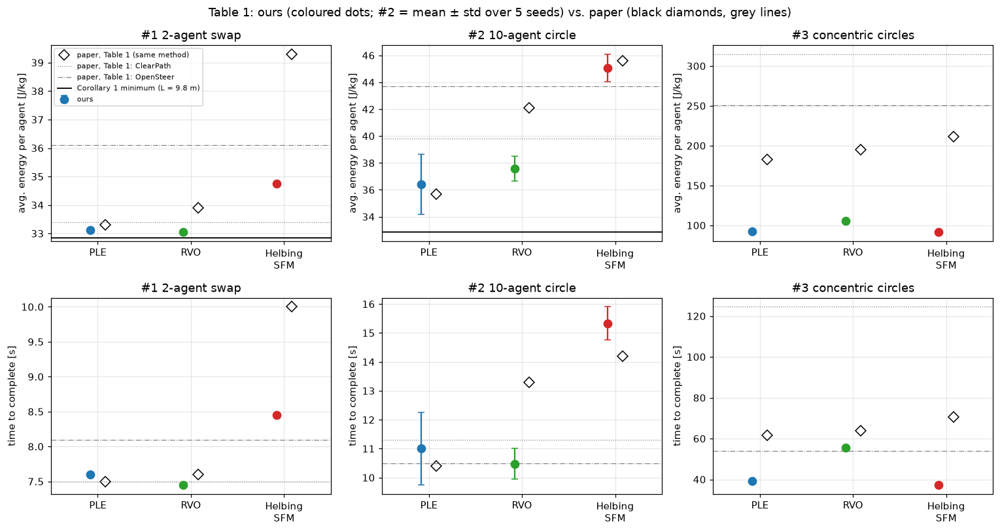

In [9]:

fig, axes = plt.subplots(2, 3, figsize=(14, 7.5))
scen = [("swap2", "#1 2-agent swap"), ("circle10", "#2 10-agent circle"), ("concentric", "#3 concentric circles")]
paper_key = {"ple": "PLE", "rvo": "RVO", "sfm": "Helbing"}
for row, qty, unit in [(0, "energy", "J/kg"), (1, "time", "s")]:
    for k, (sc, title) in enumerate(scen):
        ax = axes[row, k]
        x = np.arange(len(models))
        vals = [np.mean([r["energy" if qty == "energy" else "t_complete"] for r in res[(sc, m)]]) for m in models]
        errs = [np.std([r["energy" if qty == "energy" else "t_complete"] for r in res[(sc, m)]]) for m in models]
        for j, m in enumerate(models):
            ax.errorbar(j - 0.08, vals[j], yerr=errs[j], fmt="o", ms=8, color=MODEL_COLORS[m], capsize=3,
                        label="ours" if j == 0 else None)
        ax.plot(x + 0.08, [PAPER_TABLE1[paper_key[m]][qty][k] for m in models], "kD", ms=7, mfc="none",
                label="paper, Table 1 (same method)")
        for j, name in enumerate(["ClearPath", "OpenSteer"]):
            ax.axhline(PAPER_TABLE1[name][qty][k], color="gray", lw=0.8, ls=[":", "-."][j],
                       label=f"paper, Table 1: {name}")
        if qty == "energy" and sc != "concentric":
            ax.axhline(min_energy(9.8), color="black", lw=1.2, label="Corollary 1 minimum (L = 9.8 m)")
        ax.set_xticks(x, ["PLE", "RVO", "Helbing\nSFM"])
        ax.set_ylabel(f"{'avg. energy per agent' if qty == 'energy' else 'time to complete'} [{unit}]")
        ax.set_title(title)
        ax.set_xlim(-0.5, len(models) - 0.5)
axes[0, 0].legend(fontsize=7, loc="upper left")
plt.suptitle("Table 1: ours (coloured dots; #2 = mean ± std over 5 seeds) vs. paper (black diamonds, grey lines)")
plt.tight_layout()
plt.savefig(RESULTS / "plot_table1.png", dpi=130)
plt.show()



**Fig. 8: two-agent paths, PLE (blue) vs. Helbing (red).** The same
layout as the paper: stars mark starts, circles mark goals. Note that the
paper's figure may not use equal axis scales.


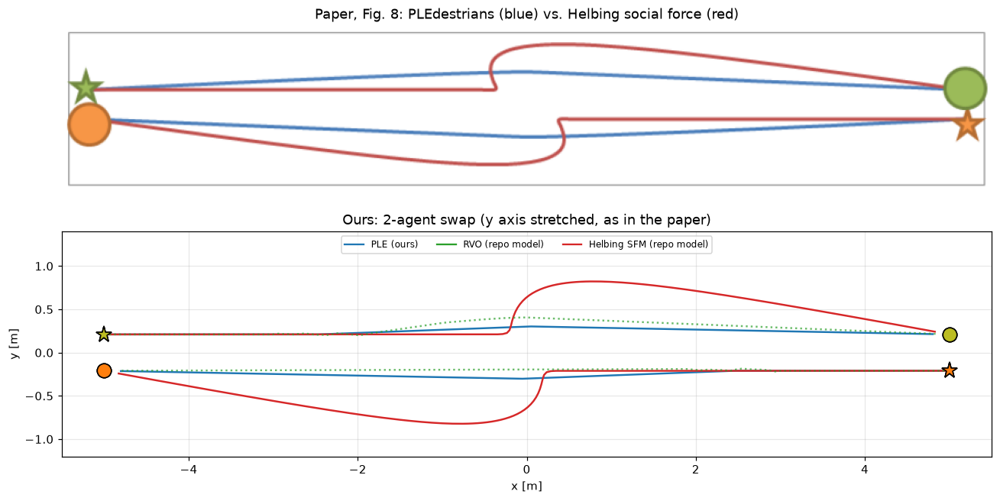

PLE (ours)                 max lateral deviation per agent: [0.092 0.092] m
RVO (repo model)           max lateral deviation per agent: [0.196 0.024] m
Helbing SFM (repo model)   max lateral deviation per agent: [0.612 0.612] m


In [10]:

fig = plt.figure(figsize=(12, 6.2))
ax_p = fig.add_subplot(2, 1, 1)
ax_p.imshow(plt.imread(PAPER_IMG["fig8_two_agent_paths"]))
ax_p.set_title("Paper, Fig. 8: PLEdestrians (blue) vs. Helbing social force (red)")
ax_p.axis("off")
ax = fig.add_subplot(2, 1, 2)
dev = {}
for m, style in [("ple", dict(color="tab:blue")), ("sfm", dict(color="tab:red")),
                 ("rvo", dict(color="tab:green", ls=":", alpha=0.7))]:
    s, df = load_run(f"t1_swap2_{m}")
    goals = {int(k): tuple(v) for k, v in s["goals"].items()}
    t_arr = arrival_times(df, goals, 0.2)
    for aid, g in df.groupby("id"):
        g = g[g["t"] <= t_arr[aid]]
        ax.plot(g["pos_x"], g["pos_y"], lw=1.6, **style)
        y0 = g["pos_y"].iloc[0]
        dev[(m, aid)] = np.abs(g["pos_y"] - y0).max()
    for aid, (sx, sy) in s["starts"].items():
        c = "tab:olive" if sy > 0 else "tab:orange"
        ax.plot(sx, sy, "*", ms=14, color=c, mec="k")
        ax.plot(*goals[int(aid)], "o", ms=12, color=c, mec="k")
for m in ["ple", "rvo", "sfm"]:
    ax.plot([], [], color=MODEL_COLORS[m], label=MODEL_NAMES[m])
ax.legend(fontsize=8, loc="upper center", ncol=3)
ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")
ax.set_ylim(-1.2, 1.4)
ax.set_title("Ours: 2-agent swap (y axis stretched, as in the paper)")
plt.tight_layout()
plt.savefig(RESULTS / "plot_fig8_paths.png", dpi=130)
plt.show()
for m in ["ple", "rvo", "sfm"]:
    d = [v for (mm, _), v in dev.items() if mm == m]
    print(f"{MODEL_NAMES[m]:26s} max lateral deviation per agent: {np.round(d, 3)} m")



**Replays.** The 2-agent swap and the 10-agent circle (seed 1) with PLE.


In [11]:

traj, area = read_sqlite_file(str(RESULTS / "t1_swap2_ple.sqlite"))
animate(traj, area, every_nth_frame=4, radius=AGENT_RADIUS, width=700, height=450,
        title_note="Table 1 #1: 2-agent swap (PLE)")


In [12]:

traj, area = read_sqlite_file(str(RESULTS / "t1_circle10_ple_s1.sqlite"))
animate(traj, area, every_nth_frame=4, radius=AGENT_RADIUS, width=650, height=650,
        title_note="Table 1 #2: 10-agent circle (PLE, seed 1)")



**Verdict, Table 1 #1 and #2, and Fig. 8: reproduced, in absolute numbers
too.**

- **#1 (2-agent swap).** PLE uses 33.1 J/kg and takes 7.6 s, against the
  paper's 33.3 J/kg and 7.5 s. That is 1.008 × Corollary 1's minimum for
  the distance actually walked, inside the paper's "within 99%".
- **#2 (10-agent circle, 5 seeds).** PLE uses 36.4 ± 2.2 J/kg and takes
  11.0 ± 1.3 s, against the paper's 35.7 J/kg and 10.4 s.
- **Helbing baseline.** The repo's SFM lands close to the paper's Helbing
  numbers in #2 (45.1 ± 1.0 vs. 45.6 J/kg; 15.3 vs. 14.2 s). It is lower
  than the paper's in #1 (34.8 vs. 39.3 J/kg).
- **Ordering.** The paper's ordering, PLE below Helbing, holds clearly.
  PLE below RVO holds only on average in #2 (36.4 vs. 37.6 J/kg), with
  overlapping spreads, and not in #1, where the repo's RVO is as
  efficient as PLE (33.0 J/kg). The paper's RVO used 42.1 J/kg in #2, and
  its gap to PLE (15%) is much larger than ours (3%). So "PLE uses the
  least energy in all scenarios" is reproduced against Helbing, but not
  convincingly against RVO.
- **Fig. 8.** The shapes match the paper's picture. PLE's agents deviate
  at most 0.09 m from their straight lines. Helbing's deviate 0.61 m, with
  the same late, sharp sidestep followed by a long curve back.

The caveat for #2 is the one in the implementation notes: with identical
agents, PLE deadlocks in this exactly symmetric scene. The numbers above
use ±10% heterogeneous agents, which the paper's model allows but whose
distribution it does not give.



## 2. Concentric Circles (Table 1 #3, Fig. 6c): congestion avoidance

**Paper's claim** (Sec. 5.3): "In the Concentric Circles scenario, the
agents move around the congestion that starts to form in the center." The
paper shows only a snapshot (Fig. 6c) and the Table 1 numbers.

**Our setup:** as in Section 1. PLE, RVO and Helbing SFM run on the same
100 agents with the same speeds. We measure how many agents are inside
1.5 m of the centre over time (the congestion), and how close each agent's
path comes to the centre. An agent that "moves around" the congestion
keeps a larger distance.


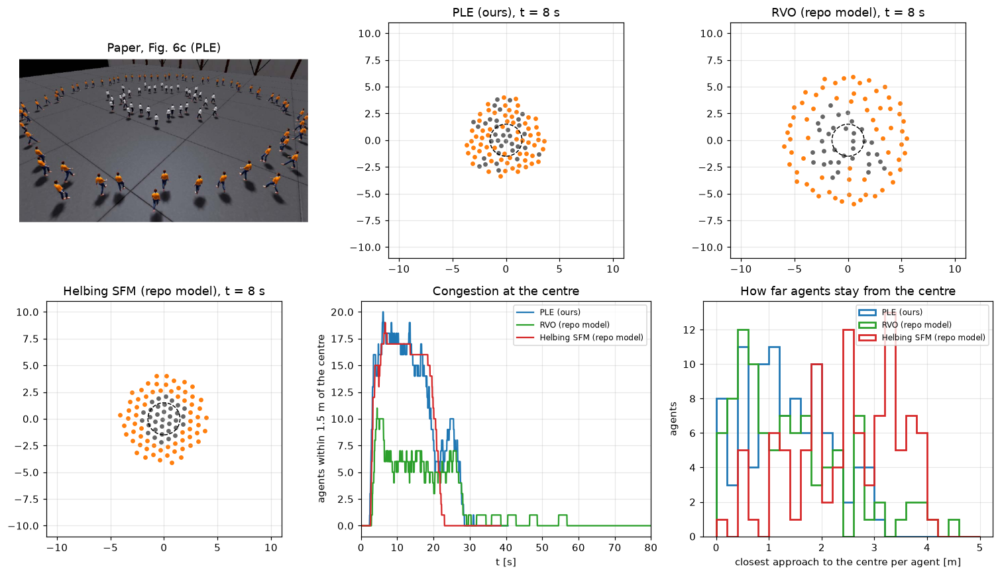

,time to complete [s],paper time [s],avg. energy [J/kg],paper energy [J/kg],peak agents within 1.5 m,median closest approach [m],min clearance [m]
method,,,,,,,
PLE (ours),39.35,61.7,92.60,183,20,1.31,-0.05
RVO (repo model),55.40,64.0,105.58,195,11,1.25,-0.22
Helbing SFM (repo model),37.30,70.5,91.43,211,19,2.58,-0.01


In [13]:

fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(2, 3)
ax_p = fig.add_subplot(gs[0, 0])
ax_p.imshow(plt.imread(PAPER_IMG["fig6c_concentric"]))
ax_p.set_title("Paper, Fig. 6c (PLE)")
ax_p.axis("off")
conc = {}
for m in models:
    s, df = load_run(f"t1_concentric_{m}")
    conc[m] = (s, df)
snap_t = 8.0
for k, m in enumerate(models):
    s, df = conc[m]
    ax = fig.add_subplot(gs[0, k + 1] if k < 2 else gs[1, 0])
    f = df[df["frame"] == df.loc[(df["t"] - snap_t).abs().idxmin(), "frame"]]
    inner = np.array([np.hypot(*s["starts"][str(a)]) < 7 for a in f["id"]], dtype=bool)
    ax.scatter(f["pos_x"][~inner], f["pos_y"][~inner], s=12, color="tab:orange", label="outer circle")
    ax.scatter(f["pos_x"][inner], f["pos_y"][inner], s=12, color="0.4", label="inner circle")
    ax.add_patch(plt.Circle((0, 0), 1.5, fill=False, ls="--", color="k"))
    ax.set_aspect("equal"); ax.set_xlim(-11, 11); ax.set_ylim(-11, 11)
    ax.set_title(f"{MODEL_NAMES[m]}, t = {snap_t:.0f} s")
ax = fig.add_subplot(gs[1, 1])
for m in models:
    s, df = conc[m]
    n_in = df.assign(r=np.hypot(df["pos_x"], df["pos_y"])).groupby("t")["r"].apply(lambda r: (r < 1.5).sum())
    ax.plot(n_in.index, n_in.to_numpy(), color=MODEL_COLORS[m], label=MODEL_NAMES[m])
ax.set_xlabel("t [s]"); ax.set_ylabel("agents within 1.5 m of the centre")
ax.set_xlim(0, 80)
ax.legend(fontsize=8)
ax.set_title("Congestion at the centre")
ax = fig.add_subplot(gs[1, 2])
bins = np.linspace(0, 5, 26)
for m in models:
    s, df = conc[m]
    rmin = df.assign(r=np.hypot(df["pos_x"], df["pos_y"])).groupby("id")["r"].min()
    ax.hist(rmin, bins=bins, histtype="step", lw=1.8, color=MODEL_COLORS[m], label=MODEL_NAMES[m])
ax.set_xlabel("closest approach to the centre per agent [m]"); ax.set_ylabel("agents")
ax.legend(fontsize=8)
ax.set_title("How far agents stay from the centre")
plt.tight_layout()
plt.savefig(RESULTS / "plot_concentric.png", dpi=130)
plt.show()

rows = []
for m in models:
    s, df = conc[m]
    r = res[("concentric", m)][0]
    rr = df.assign(r=np.hypot(df["pos_x"], df["pos_y"]))
    rows.append({"method": MODEL_NAMES[m], "time to complete [s]": r["t_complete"],
                 "paper time [s]": PAPER_TABLE1[paper_key[m]]["time"][2],
                 "avg. energy [J/kg]": r["energy"], "paper energy [J/kg]": PAPER_TABLE1[paper_key[m]]["energy"][2],
                 "peak agents within 1.5 m": rr.groupby("t")["r"].apply(lambda x: (x < 1.5).sum()).max(),
                 "median closest approach [m]": rr.groupby("id")["r"].min().median(),
                 "min clearance [m]": r["min_clearance"]})
pd.DataFrame(rows).set_index("method").round(2)


In [14]:

traj, area = read_sqlite_file(str(RESULTS / "t1_concentric_ple.sqlite"))
animate(traj, area, every_nth_frame=20, radius=AGENT_RADIUS, width=700, height=700,
        title_note="Concentric Circles, 34 + 66 agents (PLE)")



**Verdict, Concentric Circles (Table 1 #3 and Fig. 6c): shape not
reproduced, and absolute numbers not comparable.**

- **Energy and time.** All 100 PLE agents arrive, by 39.4 s, using
  92.6 J/kg on average. The paper reports 61.7 s and 183 J/kg. The circle
  radii are not published, so these absolute numbers are not comparable:
  ours come from our 10 m / 5.15 m choice.
- **Ranking.** The ranking *can* be compared, and it does not reproduce.
  The repo's Helbing SFM does as well as PLE here: 91.4 J/kg and 37.3 s,
  against the paper's 211 J/kg and 70.5 s for Helbing. The repo's RVO gets
  98 of 100 agents home by 55.4 s (89.7 J/kg for those 98). Its other two
  end up stuck against inner-circle agents standing on their goals. The
  inner goal ring has 0.95 m spacing, so the gaps are 0.35 m for 0.6 m-wide
  agents. The paper has PLE lowest (183 < RVO 195 < Helbing 211).
- **Congestion avoidance.** We see no sign that PLE agents "move around
  the congestion that starts to form in the center". At the peak, 20 of
  them are within 1.5 m of the centre, and at least 10 are there for 17 s.
  Their median closest approach to the centre is 1.31 m, against 2.58 m
  for SFM. PLE clears the jam, but by pushing through it, not around it.
  The paper attributes congestion avoidance partly to its unpublished
  cluster constraints (Sec. 4.4), which we did not implement.
- **Clearance.** The minimum clearance is −0.05 m for PLE, a shallow
  overlap in the densest moments where `PV_A` is empty. It is −0.22 m for
  RVO and −0.01 m for SFM.



## 3. Long Corridor (Figs. 6a and 9): edge effect, uneven densities, overtaking

**Paper's setup** (Sec. 5.1, 5.3): 10,000 agents fill a 300 m corridor;
"the agents all have a random goal that is located 100m or more south of
their initial position". Fig. 9 plots the average speed across a
cross-section of the 25 m corridor. Agents at the edges move 33% faster
than those in the centre. The paper also says the scene shows overtaking at
the sides and uneven densities (Fig. 6a).

**Our setup:** the same width (25 m), density (10,000 / (300 × 25) =
1.33 agents/m²) and goal rule. Each goal's lateral position is random
across the corridor, and it lies 100–120 m south of the agent's start. We
fill a **40 m** block instead of 300 m, i.e. 1,300 agents instead of
10,000, so the run takes minutes in this pure-Python callback. Agents start
on a jittered hexagonal lattice with ±10% heterogeneous speeds (as in
Section 1). We measure over t = 10–39 s, using only agents more than 3 m
from the crowd's free front and back. Those boundary layers thin out into
empty corridor, and the paper's 300 m crowd has almost none of them. The
paper does not say whether "speed" means the speed or its southward
component, so we show both.


In [15]:

s_c, df_c = load_run("corridor_main")
dv_c = add_velocity(df_c)
prof = lateral_speed_profile(dv_c, s_c["width"], 10.0, s_c["sim_time"] - 1.0, bin_w=1.0)
centre = prof[(prof["x"] > 10.5) & (prof["x"] < 14.5)]
edges_ = prof[(prof["x"] < 1.5) | (prof["x"] > s_c["width"] - 1.5)]
ratio = edges_["speed"].mean() / centre["speed"].mean()
ratio_s = edges_["speed_south"].mean() / centre["speed_south"].mean()
print(f"agents: {s_c['n_agents']}, crashed: {s_c['crashed']}, dead-reckoning drift: {s_c['max_dead_reckoning_drift']:.1e} m, "
      f"min clearance: {min_clearance(df_c[df_c['t'] >= 10], s_c['radius']):+.3f} m")
print(f"edge / centre speed ratio: {ratio:.3f} (speed), {ratio_s:.3f} (southward speed); paper: {PAPER_EDGE_RATIO}")
p9 = np.array(PAPER_FIG9["speed"])
print(f"paper Fig. 9 digitized: edges {p9[[0, -1]].mean():.3f} m/s, centre {p9[11:13].mean():.3f} m/s, "
      f"ratio {p9[[0, -1]].mean() / p9[11:13].mean():.3f}")
prof.round(3).T


agents: 1325, crashed: None, dead-reckoning drift: 0.0e+00 m, min clearance: -0.001 m
edge / centre speed ratio: 1.025 (speed), 1.026 (southward speed); paper: 1.33
paper Fig. 9 digitized: edges 1.329 m/s, centre 1.023 m/s, ratio 1.298


,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
x,0.500,1.500,2.500,3.500,4.500,5.500,6.500,7.500,8.500,9.500,...,15.500,16.500,17.500,18.500,19.500,20.500,21.500,22.500,23.500,24.500
speed,1.362,1.304,1.326,1.338,1.348,1.339,1.325,1.323,1.324,1.329,...,1.323,1.321,1.329,1.332,1.319,1.305,1.308,1.329,1.330,1.348
speed_south,1.362,1.302,1.323,1.334,1.344,1.334,1.321,1.319,1.321,1.327,...,1.321,1.319,1.326,1.328,1.314,1.300,1.303,1.326,1.328,1.348
n,750.000,1613.000,2622.000,3756.000,5540.000,6223.000,7400.000,7719.000,7479.000,8243.000,...,8525.000,7981.000,8763.000,7855.000,6331.000,4701.000,3384.000,2709.000,1700.000,620.000


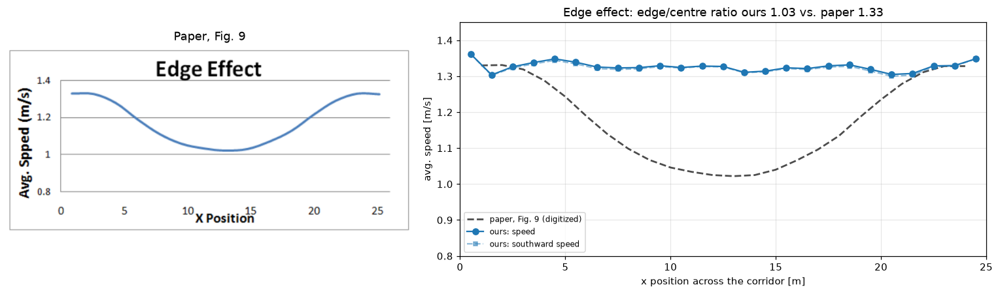

In [16]:

fig, (ax_p, ax) = plt.subplots(1, 2, figsize=(14, 4.2), gridspec_kw={"width_ratios": [1, 1.3]})
ax_p.imshow(plt.imread(PAPER_IMG["fig9_edge_effect"]))
ax_p.set_title("Paper, Fig. 9"); ax_p.axis("off")
ax.plot(PAPER_FIG9["x"], PAPER_FIG9["speed"], label="paper, Fig. 9 (digitized)", lw=1.8, **PAPER_STYLE)
ax.plot(prof["x"], prof["speed"], "o-", color="tab:blue", label="ours: speed")
ax.plot(prof["x"], prof["speed_south"], "s--", color="tab:blue", alpha=0.5, ms=4, label="ours: southward speed")
ax.set_xlabel("x position across the corridor [m]"); ax.set_ylabel("avg. speed [m/s]")
ax.set_ylim(0.8, 1.45); ax.set_xlim(0, 25)
ax.set_title(f"Edge effect: edge/centre ratio ours {ratio:.2f} vs. paper {PAPER_EDGE_RATIO}")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(RESULTS / "plot_fig9_edge_effect.png", dpi=130)
plt.show()


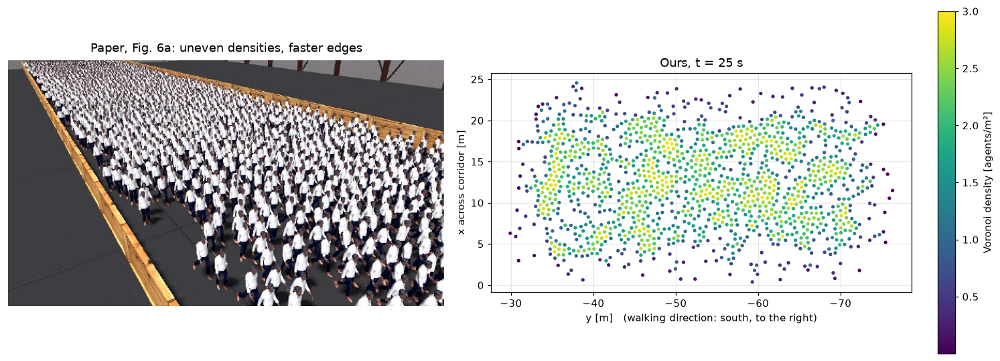

crowd body at t = 25 s: density mean 1.80, std 0.73, 5-95% range 0.44-2.78 agents/m^2


In [17]:

poly = shapely.Polygon([(0, s_c["south_end"]), (s_c["width"], s_c["south_end"]), (s_c["width"], 2), (0, 2)])
snap = dv_c[np.isclose(dv_c["t"], 25.0)]
rho = voronoi_density(snap[["pos_x", "pos_y"]].to_numpy(), poly)
fig, (ax_p, ax) = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [1, 1.2]})
ax_p.imshow(plt.imread(PAPER_IMG["fig6a_long_corridor"]))
ax_p.set_title("Paper, Fig. 6a: uneven densities, faster edges"); ax_p.axis("off")
sc = ax.scatter(snap["pos_y"], snap["pos_x"], c=np.clip(rho, 0, 3), s=6, cmap="viridis")
plt.colorbar(sc, ax=ax, label="Voronoi density [agents/m²]")
ax.set_xlabel("y [m]   (walking direction: south, to the right)"); ax.set_ylabel("x across corridor [m]")
ax.set_aspect("equal"); ax.invert_xaxis()
ax.set_title("Ours, t = 25 s")
plt.tight_layout()
plt.savefig(RESULTS / "plot_fig6a_corridor_snapshot.png", dpi=130)
plt.show()
body = pd.concat([f for _, f in snap.assign(rho=rho).groupby("frame")])
from analysis import crowd_body
b = crowd_body(body)
print(f"crowd body at t = 25 s: density mean {b['rho'].mean():.2f}, std {b['rho'].std():.2f}, "
      f"5-95% range {b['rho'].quantile(0.05):.2f}-{b['rho'].quantile(0.95):.2f} agents/m^2")


In [18]:

ov = overtakes(df_c, 10.0, s_c["sim_time"] - 1.0)
ov["zone"] = np.where((ov["x"] < 5) | (ov["x"] > 20), "edge (outer 5 m each side)", "centre (middle 15 m)")
bodyall = pd.concat([crowd_body(f) for _, f in df_c[df_c["t"] >= 10].groupby("frame")])
occ = np.where((bodyall["pos_x"] < 5) | (bodyall["pos_x"] > 20), "edge (outer 5 m each side)", "centre (middle 15 m)")
share = pd.Series(occ).value_counts(normalize=True)
tab = ov.groupby("zone").size().to_frame("overtakes")
tab["share of overtakes"] = tab["overtakes"] / tab["overtakes"].sum()
tab["share of agents (occupancy)"] = share
tab.round(3)


,overtakes,share of overtakes,share of agents (occupancy)
zone,,,
centre (middle 15 m),1835,0.811,0.818
edge (outer 5 m each side),429,0.189,0.182


In [19]:

traj, area = read_sqlite_file(str(RESULTS / "corridor_main.sqlite"))
# 1,325 agents per frame: one frame every 4 s keeps the notebook small.
animate(traj, area, every_nth_frame=16, radius=AGENT_RADIUS, width=900, height=500,
        title_note="Long Corridor, 1.33 agents/m² (PLE), one frame per 4 s")



**Verdict, Long Corridor: the edge effect is not reproduced.** Uneven
densities are.

- **Edge effect.** Our speed profile across the corridor is flat at about
  1.32 m/s. The edge/centre ratio is 1.03, against the paper's 1.33 (1.30
  from our digitization of Fig. 9).
- **Uneven densities.** Clusters and gaps form: at t = 25 s the local
  density in the crowd body ranges from 0.4 to 2.8 agents/m² (5–95%).
- **Overtaking.** It happens (about 2,300 events), but not preferentially
  at the edges. The outer 5 m on each side hold 18% of the agents and see
  19% of the overtakes.
- **The crowd leaves the walls.** Unlike Fig. 6a, where the crowd fills
  the corridor up to the walls, by t = 25 s our dense core occupies
  x ≈ 3–22 m, with only scattered agents near the walls. This is why the
  outermost 1 m bins hold far fewer samples than the centre (620–750 vs.
  ~8,000). Those few edge agents walk at the same speed as the centre.

**Why the edges are not faster:** nobody is slow. Every agent walks at
close to its own desired speed wherever it is, even inside the densest
clusters. In a flow where everyone goes the same way, neighbours have
almost the same velocity, so ORCA's half-planes barely constrain anyone.
The crowd then moves as a block (Section 4 shows the same thing against
density). A centre slower than the edges needs the centre to be slowed by
something first.

**What we checked:**

- *Measurement.* The profile is the same with the southward speed
  component as with the full speed. Every 1 m bin holds at least 600
  samples.
- *Collisions.* Minimum clearance after t = 10 s is −0.001 m, so agents
  are not passing through each other.
- *Engine consistency.* The dead-reckoned position matches the engine's
  exactly.
- *Scale.* A shorter block (40 m instead of 300 m) cannot explain a flat
  profile, since every density we tried behaves the same (Section 4).
- *Dense scenes.* Where congestion does exist, speeds do drop (the Narrow
  Passage queue, Section 4).

Possible causes on the paper's side that we cannot check: the clustering
constraints of Sec. 4.4 and the agents' speed distribution, both
unpublished.



## 4. Speed vs. density (Fig. 7): Fruin and Nelson & Maclennan

**Paper's setup:** "data collected from several runs of our simulations at
various densities", compared with Fruin's commuter data (1971) and
Nelson & Maclennan's `S = 1.4(1 − 0.266ρ)`. The scene is not named. The
text only says "our results match very closely".

**Our setup:** the Long Corridor of Section 3 (the paper's dense
unidirectional scene) at initial densities of 0.3, 0.6, 1.0, 1.33, 1.5,
2.0, 2.5 and 2.8 agents/m². All use a 20 m block except the 1.33 run,
which is Section 3's 40 m one. For each agent we measure the density as
1/(area of its Voronoi cell, clipped to the corridor) and its speed, every
1 s over t = 5–29 s, for crowd-body agents only. We bin by area per person,
as the paper's x axis does. A run's local densities spread around its
initial one, so the bins mix runs. As a second, separately labelled source
we add the queue upstream of the Narrow Passage (Section 5), sampled the
same way.


In [20]:

samples = []
runs = [("corridor_main", 5.0, 29.0)] + [(f"corridor_rho{r}", 5.0, 29.0) for r in ["0.3", "0.6", "1.0", "1.5", "2.0", "2.5", "2.8"]]
for tag, t0, t1 in runs:
    s, df = load_run(tag)
    poly = shapely.Polygon([(0, s["south_end"]), (s["width"], s["south_end"]), (s["width"], 2), (0, 2)])
    sd = speed_density_samples(add_velocity(df), poly, t0, t1, every=4)
    sd["run"] = tag
    sd["rho0"] = s["density_initial"]
    samples.append(sd)
    print(f"{tag:16s} n={s['n_agents']:5d} crashed={s['crashed']} pv_empty_steps={s['n_pv_empty']}")
sd = pd.concat(samples, ignore_index=True)
sd = sd[np.isfinite(sd["density"]) & (sd["density"] > 0)]
sd["area_pp"] = 1.0 / sd["density"]
edges = np.array([0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.2, 1.4, 1.7, 2.0, 2.5, 3.0, 3.5, 4.0, 5.0])
sd["bin"] = pd.cut(sd["area_pp"], edges)
g = sd.groupby("bin", observed=False)["speed"]
fig7 = pd.DataFrame({"area_pp": 0.5 * (edges[:-1] + edges[1:]), "mean": g.mean().to_numpy(),
                     "q25": g.quantile(0.25).to_numpy(), "q75": g.quantile(0.75).to_numpy(),
                     "n": g.size().to_numpy()})
fig7 = fig7[fig7["n"] >= 30]
fig7["paper PLE (interp.)"] = np.interp(fig7["area_pp"], PAPER_FIG7["ple"]["area_per_person"], PAPER_FIG7["ple"]["speed"],
                                        left=np.nan, right=np.nan)
fig7["Nelson formula"] = np.clip(NELSON_K * (1 - NELSON_ALPHA / fig7["area_pp"]), 0, None)

# Second, separate data source: the queue upstream of the Narrow Passage
# (Section 5), where the flow is limited by the bottleneck. Voronoi cells
# clipped to that scene's walls; agents upstream of the entrance (x < 0).
s_np_, df_np_ = load_run("narrow_passage")
poly_np = wkt.loads(s_np_["geometry_wkt"])
dv_np = add_velocity(df_np_)
np_rows = []
for fr in sorted(dv_np.loc[(dv_np["t"] >= 5) & (dv_np["t"] <= 40), "frame"].unique())[::10]:
    f = dv_np[(dv_np["frame"] == fr) & dv_np["speed"].notna()]
    f = f.assign(density=voronoi_density(f[["pos_x", "pos_y"]].to_numpy(), poly_np))
    np_rows.append(f[f["pos_x"] < 0])
np_sd = pd.concat(np_rows)
np_sd = np_sd[np.isfinite(np_sd["density"])]
np_sd["bin"] = pd.cut(1.0 / np_sd["density"], edges)
gq = np_sd.groupby("bin", observed=False)["speed"]
fig7_np = pd.DataFrame({"area_pp": 0.5 * (edges[:-1] + edges[1:]), "mean": gq.mean().to_numpy(),
                        "n": gq.size().to_numpy()})
fig7_np = fig7_np[fig7_np["n"] >= 30]
print("Long Corridor (unidirectional):")
display(fig7.round(3))
print("Narrow Passage, upstream queue:")
fig7_np.round(3)


corridor_main    n= 1325 crashed=None pv_empty_steps=247469
corridor_rho0.3  n=  150 crashed=None pv_empty_steps=209
corridor_rho0.6  n=  306 crashed=None pv_empty_steps=3607
corridor_rho1.0  n=  483 crashed=None pv_empty_steps=24948
corridor_rho1.5  n=  728 crashed=None pv_empty_steps=99516
corridor_rho2.0  n=  960 crashed=None pv_empty_steps=223352
corridor_rho2.5  n= 1224 crashed=None pv_empty_steps=365850
corridor_rho2.8  n= 1368 crashed=None pv_empty_steps=419884
Long Corridor (unidirectional):


,area_pp,mean,q25,q75,n,paper PLE (interp.),Nelson formula
0,0.35,1.285,1.257,1.314,49348,0.581,0.336
1,0.45,1.306,1.275,1.336,32948,0.699,0.572
2,0.55,1.320,1.286,1.353,13747,0.762,0.723
3,0.65,1.322,1.285,1.359,9389,0.838,0.827
4,0.75,1.325,1.283,1.365,6858,0.946,0.903
5,0.85,1.324,1.281,1.366,5217,1.040,0.962
6,0.95,1.326,1.282,1.369,3984,1.100,1.008
7,1.10,1.324,1.276,1.372,5413,1.158,1.061
8,1.30,1.328,1.278,1.374,3395,1.202,1.114
9,1.55,1.329,1.274,1.381,3219,1.229,1.160


Narrow Passage, upstream queue:


,area_pp,mean,n
0,0.35,0.536,144
1,0.45,0.532,302
2,0.55,0.687,56


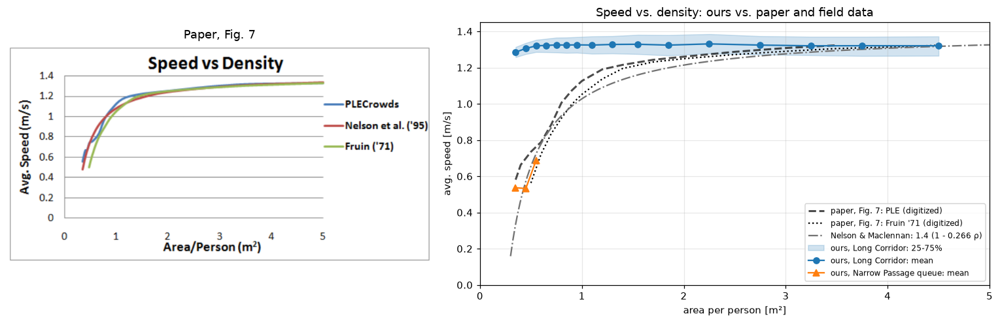

mean |ours - paper PLE| over 14 bins: 0.271 m/s; mean |ours - Nelson|: 0.304 m/s


In [21]:

fig, (ax_p, ax) = plt.subplots(1, 2, figsize=(14, 4.6), gridspec_kw={"width_ratios": [1, 1.2]})
ax_p.imshow(plt.imread(PAPER_IMG["fig7_speed_density"]))
ax_p.set_title("Paper, Fig. 7"); ax_p.axis("off")
ax.plot(PAPER_FIG7["ple"]["area_per_person"], PAPER_FIG7["ple"]["speed"], lw=2,
        label="paper, Fig. 7: PLE (digitized)", **PAPER_STYLE)
ax.plot(PAPER_FIG7["fruin"]["area_per_person"], PAPER_FIG7["fruin"]["speed"], "k:", lw=1.5,
        label="paper, Fig. 7: Fruin '71 (digitized)")
a = np.linspace(0.3, 5, 200)
ax.plot(a, NELSON_K * (1 - NELSON_ALPHA / a), color="0.45", lw=1.5, ls="-.",
        label="Nelson & Maclennan: 1.4 (1 - 0.266 ρ)")
ax.fill_between(fig7["area_pp"], fig7["q25"], fig7["q75"], color="tab:blue", alpha=0.2, label="ours, Long Corridor: 25-75%")
ax.plot(fig7["area_pp"], fig7["mean"], "o-", color="tab:blue", label="ours, Long Corridor: mean")
ax.plot(fig7_np["area_pp"], fig7_np["mean"], "^-", color="tab:orange", label="ours, Narrow Passage queue: mean")
ax.set_xlim(0, 5); ax.set_ylim(0, 1.45)
ax.set_xlabel("area per person [m²]"); ax.set_ylabel("avg. speed [m/s]")
ax.set_title("Speed vs. density: ours vs. paper and field data")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.savefig(RESULTS / "plot_fig7_speed_density.png", dpi=130)
plt.show()
m = fig7.dropna(subset=["paper PLE (interp.)"])
print(f"mean |ours - paper PLE| over {len(m)} bins: {np.abs(m['mean'] - m['paper PLE (interp.)']).mean():.3f} m/s; "
      f"mean |ours - Nelson|: {np.abs(fig7['mean'] - fig7['Nelson formula']).mean():.3f} m/s")



**Verdict, Fig. 7: not reproduced in the Long Corridor. Partly reproduced
where there is real congestion.**

- **Long Corridor.** Average speed stays at 1.29–1.33 m/s at every area
  per person from 4.5 m² down to 0.35 m², i.e. up to ~3 agents/m². The
  paper's PLE curve, and the field data (Fruin; Nelson & Maclennan), drop
  to about 0.6 m/s at 0.35 m². Our mean error against the paper's curve is
  0.27 m/s, concentrated at high density. The reason is the same as in
  Section 3: in same-direction flow ORCA's reciprocal half-planes hardly
  bind, even though `PV_A` is empty in a large share of steps in the
  dense runs.
- **Narrow Passage queue.** The dense bins read 0.53–0.69 m/s at
  0.35–0.55 m² per person, close to the paper's PLE curve (0.58–0.76 m/s)
  and to Nelson & Maclennan. This queue is slowed by the bottleneck's
  capacity, not by density itself, and it covers only three bins.

So the model can produce Fig. 7's slow, dense end where something
upstream forces a slowdown. It does not produce it in free flow.
Fig. 7's shape as a function of density is not reproduced. The paper does
not name the scene its points came from.



## 5. Narrow Passage (Fig. 6b): jamming, arching, wake

**Paper's setup** (Sec. 5.1, 5.3): "100 agents must pass through a narrow
passage to reach their goals". The paper's claims:

- **jamming and bottlenecks** form;
- agents **arch** around the entrance;
- **wake**: "people slowly spread out after the narrow passage rather than
  filling the available space immediately".

No dimensions are given.

**Our setup** (read off Fig. 6b, where a crowd squeezes between two crate
walls into open space): two 14 m × 16 m rooms joined by a passage 2.4 m
wide and 3 m long. The 100 agents start on a jittered lattice at
1.5 agents/m², 2 m before the entrance, with ±10% speeds. Each agent has
its own goal in the far half of the downstream room, at least 0.8 m from
any other goal. For the wake, we compare how far apart the agents are
laterally at several distances past the exit with where they would be if
each walked straight from its exit point to its own goal. Staying closer
together than that is the wake effect.


In [22]:

s_n, df_n = load_run("narrow_passage")
area_n = wkt.loads(s_n["geometry_wkt"])
L_n, gap_n = s_n["length"], s_n["gap"]
goals_n = {int(k): tuple(v) for k, v in s_n["goals"].items()}
t_arr_n = arrival_times(df_n, goals_n, s_n["waypoint_tolerance"])
exit_x = crossing_times(df_n, L_n)
entry_x = crossing_times(df_n, 0.0)
print(f"agents: {s_n['n_agents']}, crashed: {s_n['crashed']}, drift: {s_n['max_dead_reckoning_drift']:.1e} m")
print(f"reached their own goal: {t_arr_n.notna().mean():.0%} (paper: {PAPER_PASSAGE_ARRIVED:.0%}); "
      f"last arrival {t_arr_n.max():.1f} s")
print(f"min clearance: {min_clearance(df_n, s_n['radius']):+.3f} m; steps with empty PV: {s_n['n_pv_empty']}")
tt = np.sort(exit_x["t"].to_numpy())
steady = tt[10:90]
J = (len(steady) - 1) / (steady[-1] - steady[0])
print(f"flow through the passage (10th-90th agent): {J:.2f} agents/s = {J / gap_n:.2f} agents/(m s) over the {gap_n} m width")


agents: 100, crashed: None, drift: 0.0e+00 m
reached their own goal: 100% (paper: 100%); last arrival 45.9 s
min clearance: -0.039 m; steps with empty PV: 13005
flow through the passage (10th-90th agent): 4.37 agents/s = 1.82 agents/(m s) over the 2.4 m width


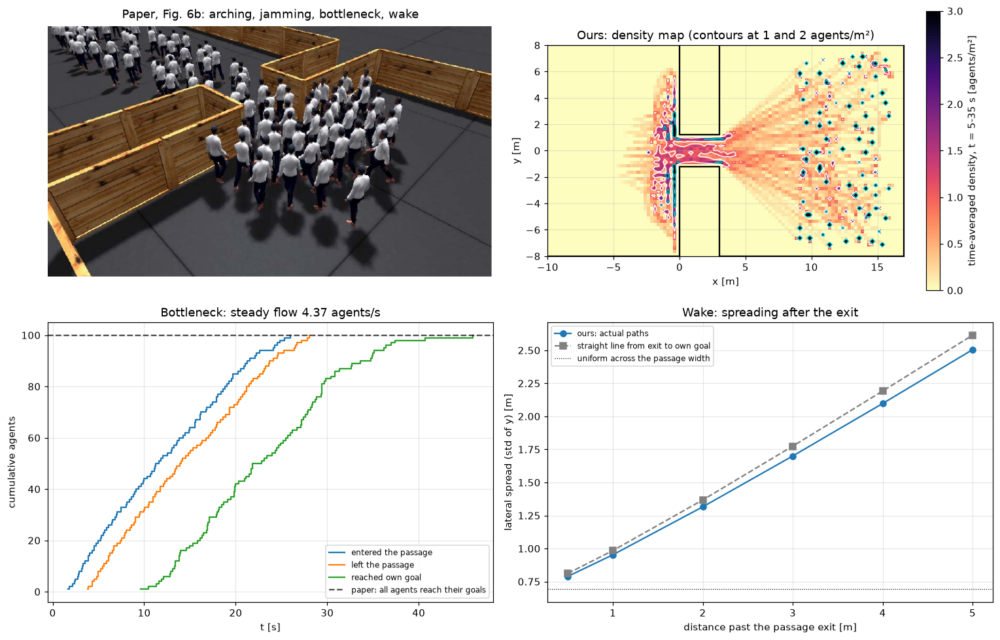

,distance past exit [m],actual spread [m],straight-line spread [m],actual / straight
0,0.5,0.789,0.812,0.972
1,1.0,0.953,0.985,0.968
2,2.0,1.316,1.368,0.962
3,3.0,1.700,1.774,0.958
4,4.0,2.097,2.192,0.957
5,5.0,2.504,2.614,0.958


In [23]:

occ, xe, ye = occupancy_map(df_n, (-10, L_n + 14), (-8, 8), cell=0.25, t0=5.0, t1=35.0)
fig = plt.figure(figsize=(14, 9))
gs = fig.add_gridspec(2, 2)
ax_p = fig.add_subplot(gs[0, 0])
ax_p.imshow(plt.imread(PAPER_IMG["fig6b_narrow_passage"]))
ax_p.set_title("Paper, Fig. 6b: arching, jamming, bottleneck, wake"); ax_p.axis("off")
ax = fig.add_subplot(gs[0, 1])
im = ax.pcolormesh(xe, ye, occ, cmap="magma_r", vmax=3)
plt.colorbar(im, ax=ax, label="time-averaged density, t = 5-35 s [agents/m²]")
ax.contour(0.5 * (xe[1:] + xe[:-1]), 0.5 * (ye[1:] + ye[:-1]), occ, levels=[1.0, 2.0], colors=["w", "c"], linewidths=1)
xs, ys = area_n.exterior.xy
ax.plot(xs, ys, "k", lw=1.5)
ax.set_aspect("equal"); ax.set_xlim(-10, L_n + 14)
ax.set_title("Ours: density map (contours at 1 and 2 agents/m²)")
ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")

ax = fig.add_subplot(gs[1, 0])
ax.step(np.sort(entry_x["t"]), np.arange(1, len(entry_x) + 1), where="post", label="entered the passage")
ax.step(tt, np.arange(1, len(tt) + 1), where="post", label="left the passage")
ax.step(np.sort(t_arr_n.dropna()), np.arange(1, t_arr_n.notna().sum() + 1), where="post", label="reached own goal")
ax.axhline(100 * PAPER_PASSAGE_ARRIVED, label="paper: all agents reach their goals", **PAPER_STYLE)
ax.set_xlabel("t [s]"); ax.set_ylabel("cumulative agents"); ax.legend(fontsize=8)
ax.set_title(f"Bottleneck: steady flow {J:.2f} agents/s")

ax = fig.add_subplot(gs[1, 1])
dists = [0.5, 1, 2, 3, 4, 5]
actual, direct = [], []
for d in dists:
    c = crossing_times(df_n, L_n + d)
    ids = c.index.intersection(exit_x.index)
    actual.append(c.loc[ids, "y"].std())
    gx = np.array([goals_n[a][0] for a in ids]); gy = np.array([goals_n[a][1] for a in ids])
    y0 = exit_x.loc[ids, "y"].to_numpy()
    direct.append((y0 + (gy - y0) * d / (gx - L_n)).std())
ax.plot(dists, actual, "o-", color="tab:blue", label="ours: actual paths")
ax.plot(dists, direct, "s--", color="gray", label="straight line from exit to own goal")
ax.axhline(gap_n / np.sqrt(12), color="k", lw=0.8, ls=":", label="uniform across the passage width")
ax.set_xlabel("distance past the passage exit [m]"); ax.set_ylabel("lateral spread (std of y) [m]")
ax.set_title("Wake: spreading after the exit"); ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(RESULTS / "plot_fig6b_narrow_passage.png", dpi=130)
plt.show()
wake_df = pd.DataFrame({"distance past exit [m]": dists, "actual spread [m]": actual,
                        "straight-line spread [m]": direct})
wake_df["actual / straight"] = wake_df["actual spread [m]"] / wake_df["straight-line spread [m]"]
wake_df.round(3)


In [24]:

# Arching: density on half-circles around the entrance, by angle. An arch
# means the crowd presses on the entrance from all directions, not only
# along the axis.
xc, yc = 0.5 * (xe[1:] + xe[:-1]), 0.5 * (ye[1:] + ye[:-1])
X, Y = np.meshgrid(xc, yc)
R, TH = np.hypot(X, Y), np.degrees(np.arctan2(Y, -X))
rows = []
for r0 in [1.0, 2.0, 3.0]:
    ring = (np.abs(R - r0) < 0.25) & (X < 0)
    for a0 in [-75, -45, -15, 15, 45, 75]:
        sel = ring & (np.abs(TH - a0) < 15)
        rows.append({"radius [m]": r0, "angle from axis [deg]": a0, "density": occ[sel].mean()})
arch = pd.DataFrame(rows).pivot(index="radius [m]", columns="angle from axis [deg]", values="density")
arch.round(2)


angle from axis [deg],-75,-45,-15,15,45,75
radius [m],,,,,,
1.0,1.63,1.14,1.16,1.13,1.42,1.90
2.0,1.44,1.07,0.86,0.55,1.41,1.49
3.0,1.17,0.68,0.24,0.17,0.35,0.89


In [25]:

traj, area = read_sqlite_file(str(RESULTS / "narrow_passage.sqlite"))
animate(traj, area, every_nth_frame=10, radius=AGENT_RADIUS, width=900, height=550,
        title_note="Narrow Passage, 100 agents (PLE)")



**Verdict, Narrow Passage: arrival and jamming reproduced. Arching partly
reproduced. Wake not reproduced.**

- **Arrival.** All 100 agents reach their own goals, by 46 s, matching
  the paper's claim. Minimum clearance is −0.039 m: a shallow overlap,
  from steps where `PV_A` is empty in the queue.
- **Jamming / bottleneck.** A dense queue forms at the entrance, and
  agents leave the passage at a steady 4.4 agents/s (1.8 agents/(m s) over
  the 2.4 m width).
- **Arching.** Within 1 m of the entrance the time-averaged density is
  similar in every direction (1.1–1.9 agents/m² from −75° to +75°), which
  is a half-ring. Further out the queue does not keep the shape of an arc.
  At 2–3 m, most people are along the wall (±75°), not on the axis. The
  crowd flattens against the wall rather than bulging into the room as in
  Fig. 6b.
- **Wake.** After the exit, agents spread 96–97% as fast as walking
  straight to their own goals would. There is almost no "slowly spread
  out" effect beyond what the goals dictate.

Our geometry and start positions are read off a picture. The arch's shape
depends on how far upstream the crowd starts and how wide it is. We did
not tune these after seeing the result.



## 6. Not reproduced: Trade-show floor (Fig. 10), Shibuya (Fig. 1), performance (Table 2)

**Trade-show floor (Fig. 10).** 1,000 agents leave an exhibition floor
(500 obstacle segments, a 300-edge roadmap), each heading to the exit
*furthest* from it. Fig. 10 shows PLE's energy per agent rising only
slowly with N, while ClearPath's and RVO's rise fast. According to the
paper, this comes from the **dynamic energy roadmap** (Sec. 4.2), which
reroutes agents around congested aisles. The floor plan, the roadmap, and
the edge-update rule's parameters are not published. We did not implement
the roadmap either (see the implementation notes). Inventing a floor plan
would not test the paper's figure. **Not attempted.** The digitized curves
are kept below for reference.

**Shibuya crossing (Fig. 1).** The comparison is visual, against real
video, on an unpublished model of the crossing. **Not attempted.**

**Table 2 (frame rates).** For reference only, we compare cost per agent
per step. This is a Python callback per agent per step, run on a machine
shared with other simulation jobs, so our wall-clock times are upper
bounds.


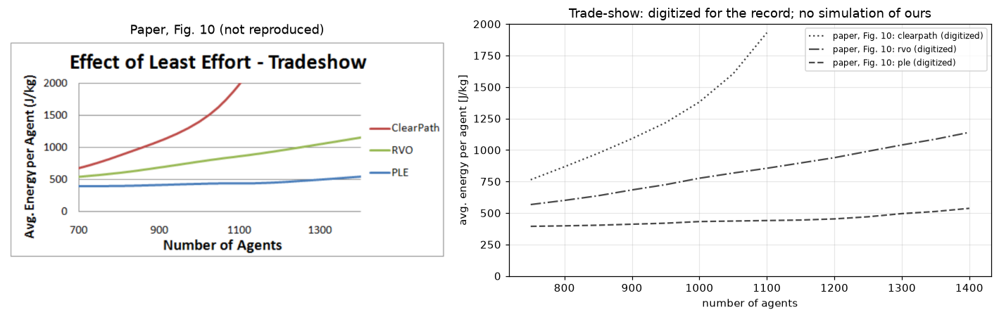

,agents,s per step,µs per agent-step
scene,,,
paper: Long Corridor,10000,0.066225,6.6
paper: Shibuya,1000,0.033445,33.4
paper: Trade-show,1000,0.032258,32.3
ours: Long Corridor (40 m block),1325,1.660451,1253.2


In [26]:

fig, (ax_p, ax) = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={"width_ratios": [1, 1.1]})
ax_p.imshow(plt.imread(PAPER_IMG["fig10_tradeshow"]))
ax_p.set_title("Paper, Fig. 10 (not reproduced)"); ax_p.axis("off")
for k, st in [("clearpath", ":"), ("rvo", "-."), ("ple", "--")]:
    ax.plot(PAPER_FIG10[k]["n_agents"], PAPER_FIG10[k]["energy"], color="black", ls=st, alpha=0.7,
            label=f"paper, Fig. 10: {k} (digitized)")
ax.set_xlabel("number of agents"); ax.set_ylabel("avg. energy per agent [J/kg]")
ax.set_ylim(0, 2000); ax.legend(fontsize=8)
ax.set_title("Trade-show: digitized for the record; no simulation of ours")
plt.tight_layout()
plt.savefig(RESULTS / "plot_fig10_not_reproduced.png", dpi=130)
plt.show()

rows = []
for name, (n, fps) in PAPER_TABLE2.items():
    rows.append({"scene": f"paper: {name}", "agents": n, "s per step": 1 / fps,
                 "µs per agent-step": 1e6 / (fps * n)})
s_c = json.loads((RESULTS / "corridor_main.json").read_text())
rows.append({"scene": "ours: Long Corridor (40 m block)", "agents": s_c["n_agents"],
             "s per step": s_c["mean_step_time_s"],
             "µs per agent-step": 1e6 * s_c["mean_step_time_s"] / s_c["n_agents"]})
perf = pd.DataFrame(rows).set_index("scene")
perf["µs per agent-step"] = perf["µs per agent-step"].round(1)
perf



**Verdict, Section 6.** Fig. 10 and Fig. 1 were not attempted, for the
reasons above. For Table 2, our implementation costs about 1.3 ms per
agent per step, against the paper's 6.6 µs in its C++ Long Corridor
(single core), about 190× slower. Even allowing for the shared machine, it
is nowhere near the paper's interactive rates. We make no claim about
hardware differences, since we did not measure them.

## 7. Summary

| # | Phenomenon (paper) | Reproduced? | Notes |
|---|---|---|---|
| 1 | Table 1 #1: 2-agent swap energy and time; "within 99% of the theoretical minimum" | ✅ | 33.1 J/kg, 7.6 s vs. paper 33.3 J/kg, 7.5 s; 1.008 × Corollary 1's minimum |
| 2 | Table 1 #2: 10-agent circle; PLE uses the least energy | ✅ absolute / ⚠️ ranking | 36.4 ± 2.2 J/kg, 11.0 ± 1.3 s vs. 35.7, 10.4. Beats Helbing SFM (45.1) clearly, the repo's RVO (37.6 ± 0.9) only within the spread. Needs ±10% heterogeneous agents: identical ones deadlock in the symmetric circle |
| 3 | Table 1 #3: concentric circles; PLE uses the least energy | ❌ ranking / — absolute | radii not published, so absolute values are not comparable (ours 92.6 J/kg, 39.4 s vs. paper 183, 61.7). Helbing SFM matches PLE here (91.4 J/kg, 37.3 s); RVO strands 2 of 100 |
| 4 | Fig. 8: PLE paths deviate less than Helbing's | ✅ | max lateral deviation 0.09 m (PLE) vs. 0.61 m (SFM); same shapes as the paper's picture |
| 5 | Fig. 6c: congestion avoidance in the concentric circles | ❌ | up to 20 PLE agents within 1.5 m of the centre, ≥ 10 for 17 s; they pass closer to the centre than SFM agents (median 1.31 vs. 2.58 m). Sec. 4.4's cluster constraints are not published or implemented |
| 6 | Fig. 9: edges 33% faster than the centre in the Long Corridor | ❌ | flat profile, edge/centre 1.03; every agent walks at about its desired speed. Checked the measurement, clearance and engine consistency |
| 7 | Fig. 6a: uneven densities; overtaking at the sides | ✅ / ⚠️ | uneven: 0.4–2.8 agents/m². Overtaking occurs but no more at the edges (19% of overtakes, 18% of agents) |
| 8 | Fig. 7: speed falls with density as in Fruin and Nelson & Maclennan | ❌ free flow / ⚠️ congested | corridor flat at 1.29–1.33 m/s down to 0.35 m² per person (paper about 0.6); the Narrow Passage queue gives 0.53–0.69 m/s at 0.35–0.55 m², close to the paper |
| 9 | Fig. 6b: all 100 agents pass the Narrow Passage; jamming | ✅ | 100% by 46 s; queue and 1.8 agents/(m s) flow |
| 10 | Fig. 6b: arching at the entrance | ⚠️ | a half-ring within 1 m of the entrance; further out the queue spreads along the wall instead of forming an arc |
| 11 | Fig. 6b: wake after the passage | ❌ | spread is 96–97% of straight-to-goal spread |
| 12 | Fig. 10: trade-show energy vs. N | ❌ not attempted | floor plan, roadmap and clustering not published; dynamic roadmap not implemented |
| 13 | Fig. 1: Shibuya vs. real video | ❌ not attempted | visual comparison on an unpublished scene |
| 14 | Table 2: interactive frame rates | ❌ | ~1.3 ms per agent-step vs. the paper's 6.6 µs (pure-Python callback, shared machine) |

**Overall.** The paper's core claim reproduces well: PLE's greedy
energy-minimising velocity choice spends close to the analytical minimum
energy and walks smooth, efficient paths in small encounters (#1, #2,
Fig. 8). Its absolute Table 1 numbers match to within a few percent. The
claims about crowd-scale phenomena mostly do not reproduce with the model
as the paper specifies it: the edge effect, the free-flow speed–density
curve, the wake, and clear congestion avoidance. In unidirectional flow,
agents with ORCA's reciprocal constraints keep their desired speed at any
density. The paper has two unpublished ingredients, the kD-tree cluster
constraints (Sec. 4.4) and the dynamic energy roadmap (Sec. 4.2). It
presents them as a speed-up and a routing aid, but they may be what
produces these effects in its figures. We could not test that.
